Here, we are going to be investigating whether there is a statistically significant relationship between the Country of Sale and Ingredients/Tags in a database of beauty products.

# Importing libraries and modules

In [65]:
import re
import requests
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from datetime import date, timedelta

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

# Loading in our Dataset

The dataset that we're looking at comes from an API endpoint. Let's look at the original output from the base url.

## Looking at original endpoint output data

In [2]:
base_url = "http://makeup-api.herokuapp.com/api/v1/products.json"

# list of all pertinent endpoint parameters
params = {
    "id": id,
    # "brand": [“almay”, “alva”, “anna sui”, “annabelle”, “benefit”, “boosh”,“burt's bees”,“butter london”, “c’est moi”, “cargo cosmetics”, “china glaze”, “clinique”, “coastal classic creation”, “colourpop”, “covergirl”, “dalish”, “deciem”, “dior”, “dr. hauschka”, “e.l.f.”, “essie”, “fenty”, “glossier”, “green people”, “iman”,“l’oreal”,“lotus cosmetics usa”, “maia's mineral galaxy”, “marcelle”, “marienatie”, “maybelline”, “milani”, “mineral fusion”, “misa”, “mistura”, “moov”, “nudus”, “nyx”,“orly”, “pacifica”, “penny lane organics”, “physicians formula”, “piggy paint”, “pure anada”, “rejuva minerals”, “revlon”, “sally b's skin yummies”, “salon perfect”,“sante”, “sinful colours”, “smashbox”, “stila”, “suncoat”, “w3llpeople”, “wet n wild”, “zorah”, “zorah biocosmetiques”], 
    "brand": "brand",
    "name": "name",
    "price": "price",
    "price_sign": "price_sign",
    "currency" : "currency",
    "rating": "rating",
    # "tag_list": ["cruelty free", "Vegan", "Chemical Free", "Organic", "Canadian", "CertClean", "Dairy Free", "EWG Verified", "EcoCert", "Fair Trade", "Gluten Free", "Hypoallergenic", "Natural", "No Talc", "Non-GMO", "Peanut Free Product", "Sugar Free", "USDA Organic", "alcohol free", "oil free", "purpicks", "silicone free", "water free"],
    "tag_list": ["tag_list"],
    "image_link": "image_link",
    "product_type" : "product_type",
    "category" : "category",
    "description": "description",
    "created_at": "created_at",
    "updated_at" : "updated_at"
    }


response = requests.get(base_url, timeout=30)
response.raise_for_status()
data = response.json()

print(data[0])

{'id': 1048, 'brand': 'colourpop', 'name': 'Lippie Pencil', 'price': '5.0', 'price_sign': '$', 'currency': 'CAD', 'image_link': 'https://cdn.shopify.com/s/files/1/1338/0845/collections/lippie-pencil_grande.jpg?v=1512588769', 'product_link': 'https://colourpop.com/collections/lippie-pencil', 'website_link': 'https://colourpop.com', 'description': 'Lippie Pencil A long-wearing and high-intensity lip pencil that glides on easily and prevents feathering. Many of our Lippie Stix have a coordinating Lippie Pencil designed to compliment it perfectly, but feel free to mix and match!', 'rating': None, 'category': 'pencil', 'product_type': 'lip_liner', 'tag_list': ['cruelty free', 'Vegan'], 'created_at': '2018-07-08T23:45:08.056Z', 'updated_at': '2018-07-09T00:53:23.301Z', 'product_api_url': 'http://makeup-api.herokuapp.com/api/v1/products/1048.json', 'api_featured_image': '//s3.amazonaws.com/donovanbailey/products/api_featured_images/000/001/048/original/open-uri20180708-4-13okqci?1531093614', 

In [3]:
data[0].keys()

dict_keys(['id', 'brand', 'name', 'price', 'price_sign', 'currency', 'image_link', 'product_link', 'website_link', 'description', 'rating', 'category', 'product_type', 'tag_list', 'created_at', 'updated_at', 'product_api_url', 'api_featured_image', 'product_colors'])

## Preprocessing the data

In [5]:
clean_data = []
for row in data:
    clean_data.append({
        "id" : row["id"],
        "brand" : row["brand"],
        "name" : row['name'],
        "price": row["price"],
        "price_sign": row["price_sign"],
        "currency" : row["currency"],
        "category" : row["category"],
        "product_type" : row["product_type"],
        "tag_list" : row["tag_list"],
        "rating" : row["rating"]
    })

df = pd.DataFrame(clean_data)
print(df.shape)
df.head(10)


(931, 10)


,id,brand,name,price,price_sign,currency,category,product_type,tag_list,rating
0,1048,colourpop,Lippie Pencil,5.0,$,CAD,pencil,lip_liner,"[cruelty free, Vegan]",NaN
1,1047,colourpop,Blotted Lip,5.5,$,CAD,lipstick,lipstick,"[cruelty free, Vegan]",NaN
2,1046,colourpop,Lippie Stix,5.5,$,CAD,lipstick,lipstick,"[cruelty free, Vegan]",NaN
3,1045,colourpop,No Filter Foundation,12.0,$,CAD,liquid,foundation,"[cruelty free, Vegan]",NaN
4,1044,boosh,Lipstick,26.0,$,CAD,lipstick,lipstick,"[Chemical Free, Organic]",NaN
5,1043,deciem,Serum Foundation,6.7,$,CAD,liquid,foundation,"[water free, cruelty free, alcohol free, oil f...",NaN
6,1042,deciem,Coverage Foundation,6.9,$,CAD,liquid,foundation,"[water free, cruelty free, alcohol free, oil f...",NaN
7,1041,zorah biocosmetiques,Liquid Liner,0.0,$,USD,liquid,eyeliner,"[purpicks, EcoCert]",NaN
8,1040,zorah biocosmetiques,Eyeshadow,0.0,$,USD,,eyeshadow,"[purpicks, EcoCert]",NaN
9,1039,w3llpeople,Realist Invisible Setting Powder,0.0,$,USD,powder,foundation,"[EWG Verified, purpicks, Gluten Free]",NaN


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            931 non-null    int64  
 1   brand         919 non-null    object 
 2   name          931 non-null    object 
 3   price         917 non-null    object 
 4   price_sign    368 non-null    object 
 5   currency      368 non-null    object 
 6   category      517 non-null    object 
 7   product_type  931 non-null    object 
 8   tag_list      931 non-null    object 
 9   rating        340 non-null    float64
dtypes: float64(1), int64(1), object(8)
memory usage: 72.9+ KB


In [7]:
# letting pandas infer appropriate data types for each column
df = df.convert_dtypes()
# correcting the dtype for the price column
df["price"] = df["price"].astype(float)

# Understanding the data

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 931 entries, 0 to 930
Data columns (total 10 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   id            931 non-null    Int64  
 1   brand         919 non-null    string 
 2   name          931 non-null    string 
 3   price         917 non-null    float64
 4   price_sign    368 non-null    string 
 5   currency      368 non-null    string 
 6   category      517 non-null    string 
 7   product_type  931 non-null    string 
 8   tag_list      931 non-null    object 
 9   rating        340 non-null    Float64
dtypes: Float64(1), Int64(1), float64(1), object(1), string(6)
memory usage: 74.7+ KB


In [9]:
df.describe(include='all')

,id,brand,name,price,price_sign,currency,category,product_type,tag_list,rating
count,931.0,919,931,917.000000,368,368,517,931,931,340.0
unique,<NA>,57,928,NaN,2,3,15,10,38,<NA>
top,<NA>,nyx,Multi Purpose Powder - Blush & Eye,NaN,$,USD,lipstick,foundation,[],<NA>
freq,<NA>,164,2,NaN,294,287,122,166,732,<NA>
mean,531.163265,NaN,NaN,16.508593,NaN,NaN,NaN,NaN,NaN,4.319118
std,311.054915,NaN,NaN,11.028035,NaN,NaN,NaN,NaN,NaN,0.675849
min,1.0,NaN,NaN,0.000000,NaN,NaN,NaN,NaN,NaN,1.5
25%,263.0,NaN,NaN,8.990000,NaN,NaN,NaN,NaN,NaN,4.0
50%,518.0,NaN,NaN,13.990000,NaN,NaN,NaN,NaN,NaN,4.5
75%,814.5,NaN,NaN,22.000000,NaN,NaN,NaN,NaN,NaN,5.0


## Let's get familiar with Countries of Sale

<StringArray>
['CAD', 'USD', <NA>, 'GBP']
Length: 4, dtype: string


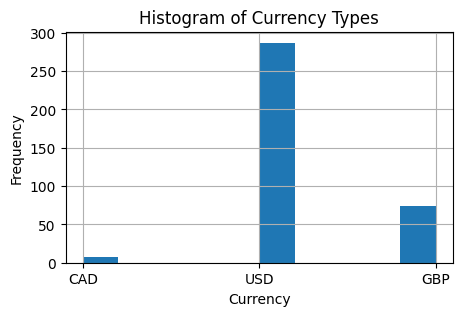

In [10]:
print(df['currency'].unique())

plt.figure(figsize=(5,3))
plt.title('Histogram of Currency Types')
df['currency'].hist()
plt.xlabel('Currency')
plt.ylabel('Frequency')
plt.show()

USD and CAD share the same currency symbol, so price_sign isn't a reliable column to include in our dataset

In [ ]:
print(df['price_sign'].unique())

<StringArray>
['$', <NA>, '£']
Length: 3, dtype: string


The dataset includes products sold in Canada, Great Britain, and the United States.

## Let's look at how many rows of data have/do not have Country of Sale info

In [12]:
# let's look at the number of rows that don't have COS info
print(df['currency'].isnull().sum())

df[df['currency'].isnull()]

563


,id,brand,name,price,price_sign,currency,category,product_type,tag_list,rating
274,772,clinique,Clinique Pop&trade; Oil Lip & Cheek Glow,NaN,<NA>,<NA>,<NA>,blush,[],<NA>
369,657,iman,Cover Cream Clay Medium Deep,NaN,<NA>,<NA>,cream,foundation,[],<NA>
370,656,iman,Corrective Concealer Clay,NaN,<NA>,<NA>,concealer,foundation,[],<NA>
371,655,iman,CC Correct & Cover Clay Medium Deep,NaN,<NA>,<NA>,bb_cc,foundation,[],<NA>
372,654,iman,Luxury Blushing Powder Posh,NaN,<NA>,<NA>,powder,blush,[],<NA>
...,...,...,...,...,...,...,...,...,...,...
926,5,pacifica,Pacifica Stellar Gaze Length & Strength Minera...,28.00,<NA>,<NA>,<NA>,mascara,"[Natural, Vegan]",4.2
927,4,physicians formula,Physicians Formula Organic Wear FakeOut Mascara,15.79,<NA>,<NA>,<NA>,mascara,"[Natural, Gluten Free]",3.9
928,3,physicians formula,Physicians Formula Organic Wear Lash Boosting ...,15.79,<NA>,<NA>,<NA>,mascara,"[Natural, Gluten Free]",3.7
929,2,<NA>,L' Oreal Paris Voluminous Mascara,9.99,<NA>,<NA>,<NA>,mascara,[],4.5


In [13]:
# let's look at the number of rows that DO have COS info
df[~df['currency'].isnull()]

,id,brand,name,price,price_sign,currency,category,product_type,tag_list,rating
0,1048,colourpop,Lippie Pencil,5.0,$,CAD,pencil,lip_liner,"[cruelty free, Vegan]",<NA>
1,1047,colourpop,Blotted Lip,5.5,$,CAD,lipstick,lipstick,"[cruelty free, Vegan]",<NA>
2,1046,colourpop,Lippie Stix,5.5,$,CAD,lipstick,lipstick,"[cruelty free, Vegan]",<NA>
3,1045,colourpop,No Filter Foundation,12.0,$,CAD,liquid,foundation,"[cruelty free, Vegan]",<NA>
4,1044,boosh,Lipstick,26.0,$,CAD,lipstick,lipstick,"[Chemical Free, Organic]",<NA>
...,...,...,...,...,...,...,...,...,...,...
364,662,dior,Dior Holiday Couture Collection,77.0,£,GBP,lipstick,lipstick,[],<NA>
365,661,dior,ROUGE DIOR - Fall 2017 Limited Edition,27.5,£,GBP,lipstick,lipstick,[],<NA>
366,660,dior,Rouge Dior,27.5,£,GBP,lipstick,lipstick,[],<NA>
367,659,dior,Rouge Dior Double Rouge,27.5,£,GBP,lipstick,lipstick,[],<NA>


## Let's get familiar with Product Tags (Ingredients)

Each product has a list of tags, which vary in size/length

In [14]:
list_lens = [len(tag_list) for tag_list in df['tag_list']]
np.unique(list_lens)

array([0, 1, 2, 3, 4, 5, 7, 8])

Let's identify all of the different tag values

In [15]:
all_tags = [item for sublist in df['tag_list'] for item in sublist]
np.unique(all_tags)
# solution inspired by this stackoverflow QA thread: https://stackoverflow.com/questions/716477/join-list-of-lists-in-python

array(['Canadian', 'CertClean', 'Chemical Free', 'Dairy Free',
       'EWG Verified', 'EcoCert', 'Fair Trade', 'Gluten Free',
       'Hypoallergenic', 'Natural', 'No Talc', 'Non-GMO', 'Organic',
       'Peanut Free Product', 'Sugar Free', 'USDA Organic', 'Vegan',
       'alcohol free', 'cruelty free', 'oil free', 'purpicks',
       'silicone free', 'water free'], dtype='<U19')

In [16]:
df['tag_list'].iloc[0]

['cruelty free', 'Vegan']

# Cleaning the dataset before analysis

In [34]:
df_interim = df[['name','currency','tag_list']].dropna(subset=['currency'])
df_interim

,name,currency,tag_list
0,Lippie Pencil,CAD,"[cruelty free, Vegan]"
1,Blotted Lip,CAD,"[cruelty free, Vegan]"
2,Lippie Stix,CAD,"[cruelty free, Vegan]"
3,No Filter Foundation,CAD,"[cruelty free, Vegan]"
4,Lipstick,CAD,"[Chemical Free, Organic]"
...,...,...,...
364,Dior Holiday Couture Collection,GBP,[]
365,ROUGE DIOR - Fall 2017 Limited Edition,GBP,[]
366,Rouge Dior,GBP,[]
367,Rouge Dior Double Rouge,GBP,[]


In [29]:
df_interim[df_interim['tag_list'].str.len() > 0] # subsetting out all items that don't have tags

,name,currency,tag_list
0,Lippie Pencil,CAD,"[cruelty free, Vegan]"
1,Blotted Lip,CAD,"[cruelty free, Vegan]"
2,Lippie Stix,CAD,"[cruelty free, Vegan]"
3,No Filter Foundation,CAD,"[cruelty free, Vegan]"
4,Lipstick,CAD,"[Chemical Free, Organic]"
5,Serum Foundation,CAD,"[water free, cruelty free, alcohol free, oil f..."
6,Coverage Foundation,CAD,"[water free, cruelty free, alcohol free, oil f..."
7,Liquid Liner,USD,"[purpicks, EcoCert]"
8,Eyeshadow,USD,"[purpicks, EcoCert]"
9,Realist Invisible Setting Powder,USD,"[EWG Verified, purpicks, Gluten Free]"


When we filter rows based on tag_list ONLY, we're left with only *43* rows of data. However, we know that there are *368* rows that have populated currency columns. Let's try to expand our cleaned dataset, by including rows with 'name' entries that contain ingredient information 

In [44]:
claim_keywords = [
    # Natural / clean beauty
    'natural',
    'organic',
    'vegan',
    'cruelty',
    'gluten',
    'eco',
    'ecocert',
    'botanical',
    'plant']

pattern = '|'.join(word for word in claim_keywords)

print(df_interim[df_interim['name'].str.lower().str.contains(pattern, na=False)].shape)
df_interim[df_interim['name'].str.lower().str.contains(pattern, na=False)]

(0, 3)


,name,currency,tag_list


In [46]:
print(df[df['name'].str.lower().str.contains(pattern, na=False)].shape)
df[df['name'].str.lower().str.contains(pattern, na=False)].head()

(21, 10)


,id,brand,name,price,price_sign,currency,category,product_type,tag_list,rating
400,625,benefit,soft & natural brows kit,44.00,<NA>,<NA>,<NA>,eyebrow,[],<NA>
495,484,physicians formula,Physicians Formula Organic Wear 100% Natural O...,21.99,<NA>,<NA>,<NA>,bronzer,"[Gluten Free, Natural]",2.5
539,438,physicians formula,Physicians Formula Organic Wear Bronzer & Blush,21.99,<NA>,<NA>,<NA>,bronzer,"[Gluten Free, Natural]",4.9
606,366,maybelline,Maybelline Mineral Power Natural Perfecting Po...,14.99,<NA>,<NA>,mineral,foundation,[],3.9
609,362,covergirl,CoverGirl Outlast Stay Luminous Foundation Cre...,12.49,<NA>,<NA>,liquid,foundation,[],<NA>


Interestingly, it appears that there are zero rows with non-NAN currency values that also contain natural/clean beauty claim keywords. So, we will continue the analysis using only the data that contains tags and currency information.

In [51]:
# subsetting out entries missing Currency Values and missing Tag values
df_clean = df_interim[df_interim['tag_list'].str.len() > 0][['currency', 'tag_list']]
df_clean = df_clean.explode('tag_list')
print(df_clean.shape)
df_clean.head()

(135, 2)


,currency,tag_list
0,CAD,cruelty free
0,CAD,Vegan
1,CAD,cruelty free
1,CAD,Vegan
2,CAD,cruelty free


# Analyzing the data to identify patterns between Ingredients/Tags and Countries/Currency

In [53]:
df_clean

,currency,tag_list
0,CAD,cruelty free
0,CAD,Vegan
1,CAD,cruelty free
1,CAD,Vegan
2,CAD,cruelty free
...,...,...
42,USD,Hypoallergenic
42,USD,No Talc
43,USD,purpicks
43,USD,Organic


In [69]:
pd.crosstab(
    df_clean['currency'],
    df_clean['tag_list'],
    normalize='index' # accounts for different sample sizes
).round(3)

tag_list,CertClean,Chemical Free,EWG Verified,EcoCert,Gluten Free,Hypoallergenic,No Talc,Organic,USDA Organic,Vegan,alcohol free,cruelty free,oil free,purpicks,silicone free,water free
currency,,,,,,,,,,,,,,,,
CAD,0.00,0.042,0.000,0.000,0.083,0.000,0.000,0.042,0.000,0.250,0.083,0.25,0.083,0.000,0.083,0.083
USD,0.09,0.009,0.135,0.027,0.054,0.072,0.072,0.081,0.063,0.063,0.000,0.00,0.000,0.333,0.000,0.000


creating a binary variable for different claims

In [60]:
natural_tags = [
    'CertClean',
    'EMG Verified',
    'Organic',
    'USDA Organic',
    'EcoCert',
    'purpicks']

exposure_tags = [
    'No Talc',
    'Alcohol Free',
    'Chemical Free',
    'Dairy Free',
    'Gluten Free',
    'Hypoallergenic',
    'Peanut Free Product',
    'Sugar Free',
    'oil free',
    'silicone free',
    'water free'
]

ethical_tags = [
    'Vegan',
    'cruelty free',
    'Fair Trade'
]

In [61]:
df_clean['natural_product'] = np.where(df_clean['tag_list'].isin(natural_tags), 1, 0)
df_clean['free_product'] = np.where(df_clean['tag_list'].isin(exposure_tags), 1, 0)
df_clean['ethical_product'] = np.where(df_clean['tag_list'].isin(ethical_tags), 1, 0)
df_clean

,currency,tag_list,natural_product,free_product,ethical_product
0,CAD,cruelty free,0,0,1
0,CAD,Vegan,0,0,1
1,CAD,cruelty free,0,0,1
1,CAD,Vegan,0,0,1
2,CAD,cruelty free,0,0,1
...,...,...,...,...,...
42,USD,Hypoallergenic,0,1,0
42,USD,No Talc,0,1,0
43,USD,purpicks,1,0,0
43,USD,Organic,1,0,0


In [62]:
df_clean.groupby('currency')['natural_product'].mean()

currency
CAD    0.041667
USD    0.594595
Name: natural_product, dtype: float64

In [63]:
df_clean.groupby('currency')['free_product'].mean()

currency
CAD    0.375000
USD    0.207207
Name: free_product, dtype: float64

In [64]:
df_clean.groupby('currency')['ethical_product'].mean()

currency
CAD    0.500000
USD    0.063063
Name: ethical_product, dtype: float64

## Visualizations

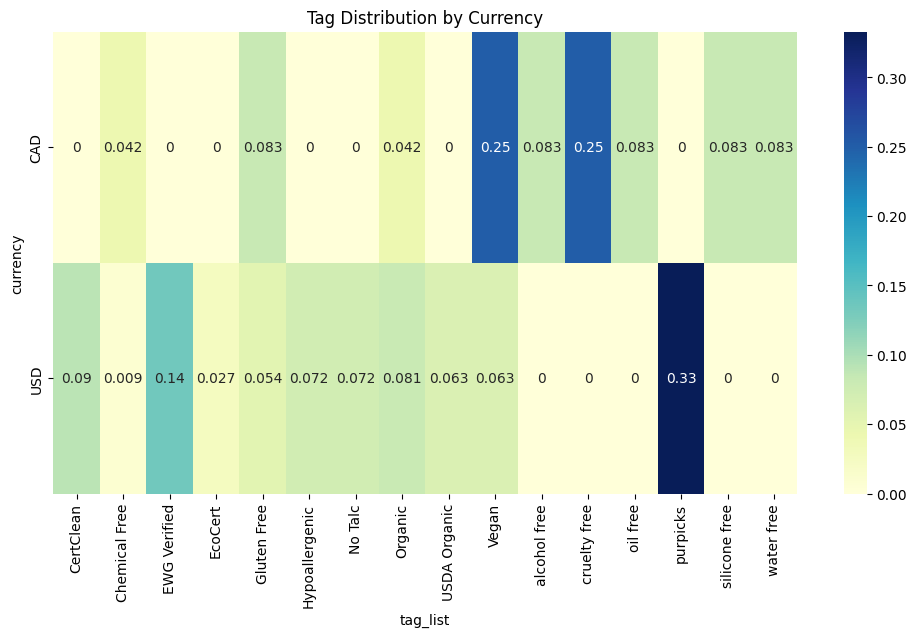

In [ ]:
tag_percentages = pd.crosstab(df_clean['currency'], df_clean['tag_list'], normalize='index').round(3)

plt.figure(figsize=(12,6))
sns.heatmap(
    tag_percentages,
    annot=True,
    cmap='YlGnBu'
)
plt.title("Tag Distribution by Currency")
plt.show()

In [73]:
country_summary = (df_clean.groupby('currency')[['natural_product','free_product','ethical_product']].mean()* 100)
country_summary

,natural_product,free_product,ethical_product
currency,,,
CAD,4.166667,37.500000,50.000000
USD,59.459459,20.720721,6.306306


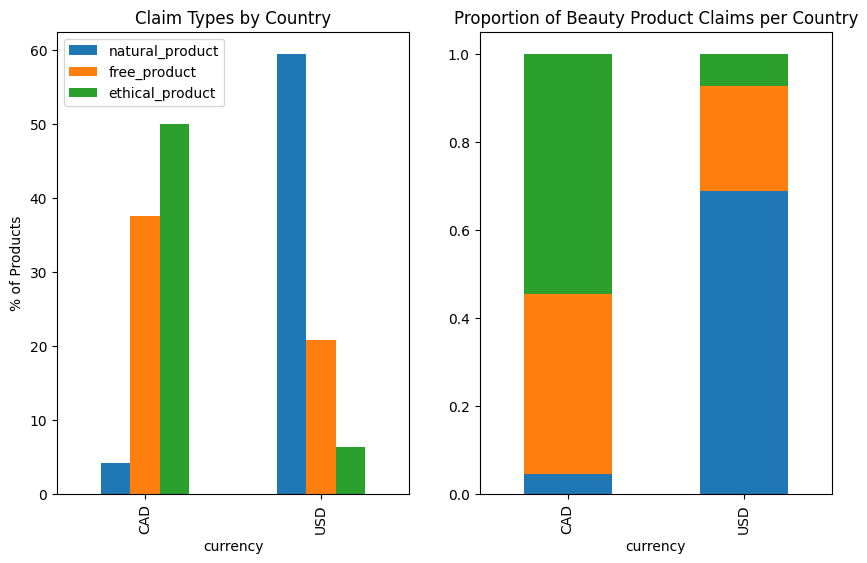

In [81]:
fix, ax = plt.subplots(1,2, figsize=(18,6))
country_summary.plot(ax=ax[0], title='Claim Types by Country', 
                     kind='bar', figsize=(10,6))
ax[0].set_ylabel('% of Products')
country_summary.div(country_summary.sum(axis=1),axis=0).plot(
    ax=ax[1], title='Proportion of Beauty Product Claims per Country',
    kind='bar', legend=False,
    stacked=True)
plt.show()

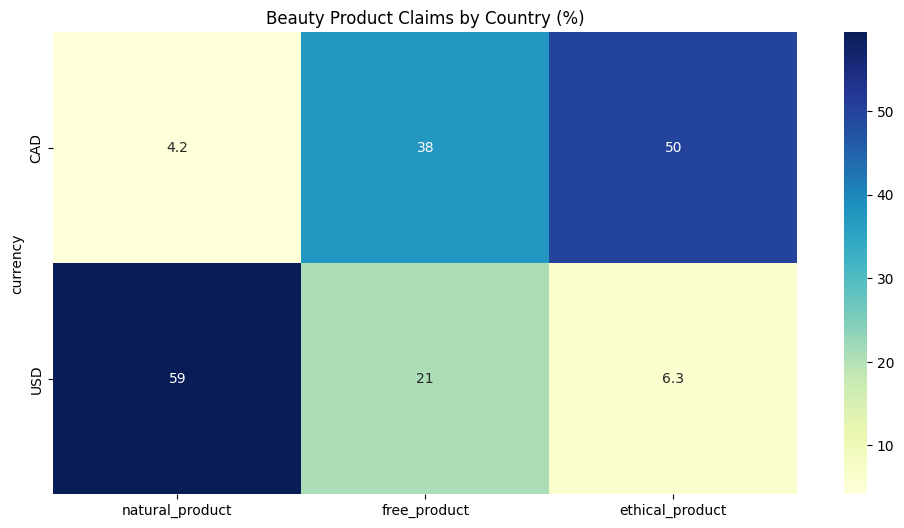

In [75]:
plt.figure(figsize=(12,6))
sns.heatmap(
    country_summary,
    annot=True,
    cmap='YlGnBu')
plt.title('Beauty Product Claims by Country (%)')
plt.show()